In [84]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import r2_score

In [2]:
url = r'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/medical_insurance_dataset.csv'

In [6]:
df = pd.read_csv(url, header = None)

In [7]:
df.head(10)

,0,1,2,3,4,5,6
0,19,1,27.900,0,1,3,16884.92400
1,18,2,33.770,1,0,4,1725.55230
2,28,2,33.000,3,0,4,4449.46200
3,33,2,22.705,0,0,1,21984.47061
4,32,2,28.880,0,0,1,3866.85520
5,31,1,25.740,0,?,4,3756.62160
6,46,1,33.440,1,0,4,8240.58960
7,37,1,27.740,3,0,1,7281.50560
8,37,2,29.830,2,0,2,6406.41070
9,60,1,25.840,0,0,1,28923.13692


In [9]:
headers = ['age', 'gender', 'bmi', 'no_of_children', 'smoker', 'region', 'charges']
df.columns = headers

In [11]:
df.head(10)

,age,gender,bmi,no_of_children,smoker,region,charges
0,19,1,27.900,0,1,3,16884.92400
1,18,2,33.770,1,0,4,1725.55230
2,28,2,33.000,3,0,4,4449.46200
3,33,2,22.705,0,0,1,21984.47061
4,32,2,28.880,0,0,1,3866.85520
5,31,1,25.740,0,?,4,3756.62160
6,46,1,33.440,1,0,4,8240.58960
7,37,1,27.740,3,0,1,7281.50560
8,37,2,29.830,2,0,2,6406.41070
9,60,1,25.840,0,0,1,28923.13692


In [14]:
df.replace("?",np.nan, inplace = True)
missing_values = df.isnull()
missing_values.head(10)

,age,gender,bmi,no_of_children,smoker,region,charges
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
5,False,False,False,False,True,False,False
6,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False


In [21]:
columns = ['age', 'gender', 'bmi', 'no_of_children', 'smoker', 'region', 'charges']
for column in columns:
    print(f"for column {column} the value counts are :\n", missing_values[column].value_counts())
    print("--------")

for column age the value counts are :
 age
False    2768
True        4
Name: count, dtype: int64
--------
for column gender the value counts are :
 gender
False    2772
Name: count, dtype: int64
--------
for column bmi the value counts are :
 bmi
False    2772
Name: count, dtype: int64
--------
for column no_of_children the value counts are :
 no_of_children
False    2772
Name: count, dtype: int64
--------
for column smoker the value counts are :
 smoker
False    2765
True        7
Name: count, dtype: int64
--------
for column region the value counts are :
 region
False    2772
Name: count, dtype: int64
--------
for column charges the value counts are :
 charges
False    2772
Name: count, dtype: int64
--------


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             2768 non-null   object 
 1   gender          2772 non-null   int64  
 2   bmi             2772 non-null   float64
 3   no_of_children  2772 non-null   int64  
 4   smoker          2765 non-null   object 
 5   region          2772 non-null   int64  
 6   charges         2772 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 151.7+ KB


In [22]:
missing_counts = df.isnull().sum()
print(missing_counts)

age               4
gender            0
bmi               0
no_of_children    0
smoker            7
region            0
charges           0
dtype: int64


In [32]:
avg_age = df['age'].fillna(0).astype("int").mean(axis = 0)
avg_age

np.float64(39.05339105339105)

In [33]:
df['age'].replace(np.nan, avg_age, inplace = True)

In [35]:
df['smoker'].value_counts()

smoker
0    2201
1     564
Name: count, dtype: int64

In [36]:
df['smoker'].replace(np.nan, '0', inplace = True)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             2772 non-null   object 
 1   gender          2772 non-null   int64  
 2   bmi             2772 non-null   float64
 3   no_of_children  2772 non-null   int64  
 4   smoker          2772 non-null   object 
 5   region          2772 non-null   int64  
 6   charges         2772 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 151.7+ KB


In [39]:
df['charges'] = df['charges'].round(2)

In [40]:
df.tail(5)

,age,gender,bmi,no_of_children,smoker,region,charges
2767,47,1,45.320,1,0,4,8569.86
2768,21,1,34.600,0,0,3,2020.18
2769,19,2,26.030,1,1,1,16450.89
2770,23,2,18.715,0,0,1,21595.38
2771,54,2,31.600,0,0,3,9850.43


(0.0, 66902.85800000001)

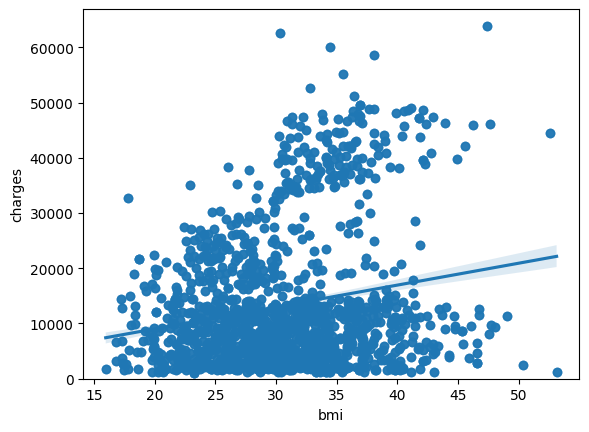

In [43]:
sns.regplot(x='bmi',y='charges',data=df)
plt.ylim(0,)

C:\Users\Mohammed Arfath\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


<Axes: xlabel='smoker', ylabel='charges'>

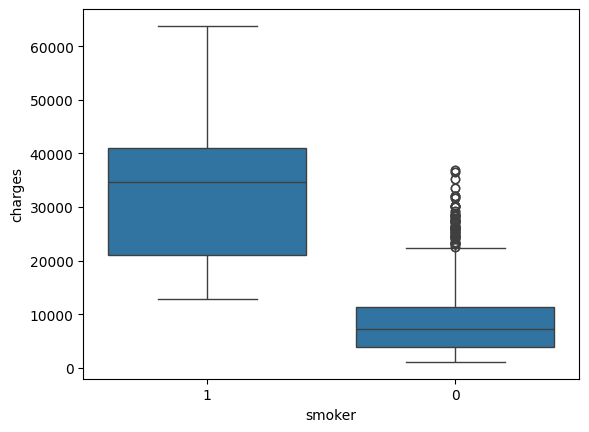

In [44]:
sns.boxplot(x='smoker' , y='charges', data = df)

In [48]:
print(df.corr())

                     age    gender       bmi  no_of_children    smoker  \
age             1.000000 -0.026043  0.113047        0.037579 -0.023286   
gender         -0.026043  1.000000  0.042924        0.016020  0.082326   
bmi             0.113047  0.042924  1.000000       -0.001492  0.011489   
no_of_children  0.037579  0.016020 -0.001492        1.000000  0.006362   
smoker         -0.023286  0.082326  0.011489        0.006362  1.000000   
region         -0.007171  0.022213  0.271119       -0.025717  0.054077   
charges         0.298623  0.062837  0.199846        0.066442  0.788783   

                  region   charges  
age            -0.007171  0.298623  
gender          0.022213  0.062837  
bmi             0.271119  0.199846  
no_of_children -0.025717  0.066442  
smoker          0.054077  0.788783  
region          1.000000  0.054058  
charges         0.054058  1.000000  


In [51]:
lm = LinearRegression()
x = df[['smoker']]
y = df[['charges']]
lm.fit(x,y)

LinearRegression()

In [52]:
lm.score(x,y)

0.6221791733924185

In [77]:
lm2 = LinearRegression()
x1 = df[["age", "gender", "bmi", "no_of_children", "smoker", "region"]]
y1 = df[['charges']]

In [78]:
lm2.fit(x1,y1)

LinearRegression()

In [79]:
lm2.score(x1,y1)

0.7504074093266571

In [80]:
from sklearn.pipeline import Pipeline

In [81]:
input = [('Scale', StandardScaler()), ('poly',PolynomialFeatures(degree = 2)),('model', LinearRegression())]
pipe = Pipeline(input)
x1 = x1.astype(float)

In [85]:
pipe.fit(x1,y)
ypipe=pipe.predict(x1)
print(r2_score(y1,ypipe))

0.8452567636137702


In [86]:
x_train, x_test, y_train, y_test = train_test_split(x1, y1, test_size = 0.2, random_state=0)

In [87]:
RigeModel = Ridge(alpha=0.1)

In [88]:
RigeModel.fit(x_train, y_train)
yhat = RigeModel.predict(x_test)

In [89]:
print(r2_score(y_test,yhat))

0.7469861345148645


In [92]:
pr = PolynomialFeatures(degree=2)
x_train_pr = pr.fit_transform(x_train)
x_test_pr = pr.transform(x_test)
RigeModel.fit(x_train_pr, y_train)
y_hat = RigeModel.predict(x_test_pr)
print(r2_score(y_test,y_hat))

0.8410006423329641
